# P-RICE: Extra Analysis (Monthly)
Runs the same pipeline as **P-RICE Model - All Rice Types (Monthly).ipynb** (Sections 1–7), then adds three analyses for Chapter 4:

- **Section 13. Ablation:** does adding the 8 market factors actually help, compared with XGBoost using price history only?
- **Section 14. Diebold-Mariano test:** is XGBoost's lower error statistically significant, or could it be chance?
- **Section 15. Future forecast:** a real forecast for the months **after** the last observed month (July 2026 onward), with the factors behind each forecast.

Results are saved to **P-RICE Extra Results.xlsx**. The main notebook and its results file are not changed.

In [1]:
# Install libraries (safe to re-run; does nothing if already installed)
%pip install -q xgboost scikit-learn pandas numpy matplotlib statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display

pd.set_option("display.width", 200)

## 1. Settings
Change these values to run different experiments.

In [3]:
# Rice data files: (Origin, Variety) -> file name
FILES = {
    ("Local", "Special"):           "Local Special Rice.csv",
    ("Local", "Premium"):           "Local Premium Rice.csv",
    ("Local", "Well-milled"):       "Local Well-milled Rice.csv",
    ("Local", "Regular-milled"):    "Local Regular-Milled Rice.csv",
    ("Imported", "Special"):        "Imported Special Rice.csv",
    ("Imported", "Premium"):        "Imported Premium Rice.csv",
    ("Imported", "Well-milled"):    "Imported Well-milled Rice.csv",
    ("Imported", "Regular-milled"): "Imported Regular-milled Rice.csv",
}

# Predictors (exogenous factors)
EXOG = ["Brent_Oil_USD", "Farmgate_LCU_tonne", "Inflation_Rate", "Stocks_MT", "USD_to_PHP", "Temp_C", "Rainfall_mm", "VoP_MT"]

FREQ = "MS"                    # "MS" = monthly. Set to None to keep the original weekly data.
HORIZONS = [1, 2, 3, 4, 5, 6]  # how many periods (months) ahead to forecast
PRICE_LAGS = 3                 # how many past months of prices the model sees
SPLIT = (0.80, 0.10, 0.10)     # train / validation / test (chronological)
N_ITER = 30                    # RandomizedSearchCV: number of random setting combinations to try
PLOT_HORIZON = 1               # horizon used for the actual-vs-predicted charts
SHAP_HORIZON = 1               # horizon used for the SHAP analysis
RANDOM_STATE = 42

# Hyperparameter search space (Table 3 of the paper)
PARAM_GRID = {
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.01, 0.03, 0.05],
    "subsample":        [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_weight": [3, 5, 10],
    "reg_alpha":        [0.1, 1.0, 5.0],
    "reg_lambda":       [1.0, 5.0, 10.0],
    "gamma":            [0.1, 0.5, 1.0],
}

## 2. Load data
Reads each rice file, keeps only the price and the base predictors (the pre-made lag columns and `Price_Change` are rebuilt later in a leakage-free way), and converts weekly data to monthly averages.

**To use new data later:** this cell just needs to produce a table with the columns `Date, Price, Origin, Variety, Series` plus the predictor columns in `EXOG`.

In [4]:
def load_series(path, origin, variety):
    d = pd.read_csv(path)
    price_col = [c for c in d.columns if "_PHP_kg_" in c and "_lag" not in c][0]
    d = d[["Date", price_col] + EXOG].rename(columns={price_col: "Price"})
    d["Date"] = pd.to_datetime(d["Date"])
    if FREQ:
        d = d.set_index("Date").resample(FREQ).mean().reset_index()   # weekly -> monthly average
    d["Origin"], d["Variety"] = origin, variety
    d["Series"] = f"{origin} {variety}"
    return d

data = pd.concat([load_series(f, o, v) for (o, v), f in FILES.items()], ignore_index=True)
SERIES = list(data["Series"].unique())

display(data)
print(data.groupby("Series")["Date"].agg(["min", "max", "count"]))

,Date,Price,Brent_Oil_USD,Farmgate_LCU_tonne,Inflation_Rate,Stocks_MT,USD_to_PHP,Temp_C,Rainfall_mm,VoP_MT,Origin,Variety,Series
0,2023-08-01,57.8000,82.50,17740.0,8.7,651930.00,56.1599,26.6500,6.2200,292142.87,Local,Special,Local Special
1,2023-09-01,58.3660,82.59,18190.0,8.6,541210.00,56.7869,27.2320,8.6220,292142.87,Local,Special,Local Special
2,2023-10-01,58.1450,78.43,18570.0,7.6,494252.94,56.7889,26.5675,8.6175,556578.48,Local,Special,Local Special
3,2023-11-01,59.4375,84.64,18790.0,6.6,728730.70,55.8122,25.8125,10.0300,556578.48,Local,Special,Local Special
4,2023-12-01,60.9660,75.47,19060.0,6.1,787970.99,55.5877,25.3680,11.2160,556578.48,Local,Special,Local Special
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,2026-02-01,40.9075,71.04,17360.0,0.9,1343908.45,58.2803,23.8375,4.7225,338099.00,Imported,Regular-milled,Imported Regular-milled
276,2026-03-01,42.4600,67.87,17060.0,1.5,1030751.52,59.4069,24.2475,1.0600,338099.00,Imported,Regular-milled,Imported Regular-milled
277,2026-04-01,43.0550,67.99,15600.0,1.7,815346.38,60.2913,27.3225,0.1025,356076.21,Imported,Regular-milled,Imported Regular-milled
278,2026-05-01,43.0600,64.54,15890.0,1.7,954908.93,61.4410,29.4520,2.1920,356076.21,Imported,Regular-milled,Imported Regular-milled


                               min        max  count
Series                                              
Imported Premium        2023-08-01 2026-06-01     35
Imported Regular-milled 2023-08-01 2026-06-01     35
Imported Special        2023-08-01 2026-06-01     35
Imported Well-milled    2023-08-01 2026-06-01     35
Local Premium           2023-08-01 2026-06-01     35
Local Regular-milled    2023-08-01 2026-06-01     35
Local Special           2023-08-01 2026-06-01     35
Local Well-milled       2023-08-01 2026-06-01     35


## 3. Chronological 80-10-10 split
The split is based on **dates**, so every rice type and every horizon is tested on the same months.

In [5]:
all_dates = np.sort(data["Date"].unique())
n_dates = len(all_dates)
TRAIN_END = all_dates[int(n_dates * SPLIT[0]) - 1]
VAL_END   = all_dates[int(n_dates * (SPLIT[0] + SPLIT[1])) - 1]

fmt = lambda d: pd.Timestamp(d).strftime("%b %Y")
print(f"Total periods : {n_dates}")
print(f"Train         : {fmt(all_dates[0])} - {fmt(TRAIN_END)}")
print(f"Validation    : after {fmt(TRAIN_END)} - {fmt(VAL_END)}")
print(f"Test          : after {fmt(VAL_END)} - {fmt(all_dates[-1])}")

Total periods : 35
Train         : Aug 2023 - Nov 2025
Validation    : after Nov 2025 - Feb 2026
Test          : after Feb 2026 - Jun 2026


## 4. Feature engineering (leakage-free)
For a forecast made at month **t** for month **t + h**:
- `Price_lag0..3`: price at t, t-1, t-2, t-3
- `Change_lag0..2`: monthly price changes up to month t
- predictors at t and t-1 (`_lag0`, `_lag1`)
- `Origin_*`, `Variety_*`: rice type as **categorical** (0/1) columns
- `Target_Month`: calendar month being forecast (seasonality)

**Target** `y` = price(t + h) − price(t). Predicted price = price(t) + predicted change.

In [6]:
META = ["Series", "Origin_Date", "Target_Date", "Base_Price", "Actual", "y", "Set"]

def make_features(df, h):
    parts = []
    for s, g in df.groupby("Series"):
        g = g.sort_values("Date").reset_index(drop=True)
        f = pd.DataFrame({"Series": s, "Origin": g["Origin"], "Variety": g["Variety"],
                          "Origin_Date": g["Date"], "Target_Date": g["Date"].shift(-h)})
        for k in range(PRICE_LAGS + 1):
            f[f"Price_lag{k}"] = g["Price"].shift(k)
        for k in range(PRICE_LAGS):
            f[f"Change_lag{k}"] = g["Price"].shift(k) - g["Price"].shift(k + 1)
        for c in EXOG:
            f[f"{c}_lag0"] = g[c]
            f[f"{c}_lag1"] = g[c].shift(1)
        f["Target_Month"] = f["Target_Date"].dt.month
        f["Base_Price"] = g["Price"]
        f["Actual"] = g["Price"].shift(-h)
        f["y"] = f["Actual"] - f["Base_Price"]
        parts.append(f)
    out = pd.concat(parts, ignore_index=True).dropna()
    out = pd.get_dummies(out, columns=["Origin", "Variety"], dtype=int)   # categorical -> 0/1 columns
    out["Set"] = np.where(out["Target_Date"] <= TRAIN_END, "Train",
                 np.where(out["Target_Date"] <= VAL_END, "Validation", "Test"))
    return out.sort_values(["Target_Date", "Series"]).reset_index(drop=True)

example = make_features(data, 1)
FEATURES = [c for c in example.columns if c not in META]
print(f"{len(FEATURES)} features:", FEATURES)
print(example["Set"].value_counts())

30 features: ['Price_lag0', 'Price_lag1', 'Price_lag2', 'Price_lag3', 'Change_lag0', 'Change_lag1', 'Change_lag2', 'Brent_Oil_USD_lag0', 'Brent_Oil_USD_lag1', 'Farmgate_LCU_tonne_lag0', 'Farmgate_LCU_tonne_lag1', 'Inflation_Rate_lag0', 'Inflation_Rate_lag1', 'Stocks_MT_lag0', 'Stocks_MT_lag1', 'USD_to_PHP_lag0', 'USD_to_PHP_lag1', 'Temp_C_lag0', 'Temp_C_lag1', 'Rainfall_mm_lag0', 'Rainfall_mm_lag1', 'VoP_MT_lag0', 'VoP_MT_lag1', 'Target_Month', 'Origin_Imported', 'Origin_Local', 'Variety_Premium', 'Variety_Regular-milled', 'Variety_Special', 'Variety_Well-milled']
Set
Train         192
Test           32
Validation     24
Name: count, dtype: int64


## 5. Model functions
- **Tuning**: RandomizedSearchCV over the Table 3 grid, using time-ordered folds (never shuffled), scored by MAE. Then early stopping on the validation set picks the number of trees (max 1000).
- **Walk-forward**: for each forecast month, retrain on all rows whose actual value was already known at that time, then predict.
- **ARIMA**: order (p, d, q) chosen by lowest AIC on the training period only, then re-fitted at every walk-forward step.
- **Naive**: forecast = latest known price.

In [7]:
def time_folds(frame, n_splits=3):
    # Cross-validation folds split by date (earlier dates train, later dates validate)
    ud = np.sort(frame["Target_Date"].unique())
    folds = []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(ud):
        folds.append((np.where(frame["Target_Date"].isin(ud[tr]))[0],
                      np.where(frame["Target_Date"].isin(ud[te]))[0]))
    return folds

def tune_xgb(feat):
    train = feat[feat["Set"] == "Train"].reset_index(drop=True)
    val = feat[feat["Set"] == "Validation"]
    search = RandomizedSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", n_estimators=300, random_state=RANDOM_STATE),
        PARAM_GRID, n_iter=N_ITER, cv=time_folds(train), scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(train[FEATURES], train["y"])
    params = search.best_params_
    # Early stopping on the validation set (n_estimators up to 1000)
    es = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=1000, early_stopping_rounds=50,
                          eval_metric="mae", random_state=RANDOM_STATE, **params)
    es.fit(train[FEATURES], train["y"], eval_set=[(val[FEATURES], val["y"])], verbose=False)
    return params, es.best_iteration + 1

def walk_forward_xgb(feat, params, n_rounds):
    eval_rows = feat[feat["Set"] != "Train"]
    pred = pd.Series(index=eval_rows.index, dtype=float)
    model = None
    for origin in np.sort(eval_rows["Origin_Date"].unique()):
        known = feat[feat["Target_Date"] <= origin]            # only data known at forecast time
        model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=n_rounds,
                                 random_state=RANDOM_STATE, **params)
        model.fit(known[FEATURES], known["y"])
        idx = eval_rows.index[eval_rows["Origin_Date"] == origin]
        pred.loc[idx] = model.predict(feat.loc[idx, FEATURES])
    return feat.loc[eval_rows.index, "Base_Price"] + pred, model   # price = current price + predicted change

def choose_arima_order(y_train):
    best, best_aic = (1, 1, 0), np.inf
    for p in range(3):
        for d in range(2):
            for q in range(3):
                try:
                    aic = ARIMA(y_train, order=(p, d, q)).fit().aic
                    if aic < best_aic:
                        best, best_aic = (p, d, q), aic
                except Exception:
                    pass
    return best

def mape(a, p):
    a, p = np.asarray(a), np.asarray(p)
    return np.mean(np.abs((a - p) / a)) * 100

def scores(a, p):
    return {"MAE": mean_absolute_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAPE (%)": mape(a, p)}

## 6. ARIMA orders (chosen on training data only)

In [8]:
arima_orders = {}
for s in SERIES:
    y_tr = data[(data["Series"] == s) & (data["Date"] <= TRAIN_END)].sort_values("Date")["Price"].values
    arima_orders[s] = choose_arima_order(y_tr)
pd.Series(arima_orders, name="ARIMA (p, d, q)").to_frame()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters f

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarnin

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible sta

,"ARIMA (p, d, q)"
Local Special,"(0, 1, 0)"
Local Premium,"(1, 1, 1)"
Local Well-milled,"(0, 1, 2)"
Local Regular-milled,"(2, 1, 1)"
Imported Special,"(0, 1, 1)"
Imported Premium,"(1, 1, 0)"
Imported Well-milled,"(0, 1, 1)"
Imported Regular-milled,"(1, 1, 0)"


## 6b. How many lags should the model use?
Two checks, both using **training/validation data only** (the test set stays unseen):

**Method 1: PACF (Partial Autocorrelation Function).** For each lag k, it measures how much the price k months ago still tells us about today's price, *after* removing the effect of the months in between. Bars outside the blue band are statistically significant. The last significant lag suggests how far back the model should look.

**Method 2: Lag search (experiment).** Try `PRICE_LAGS` = 1 to 6, run walk-forward on the **validation set**, and pick the number with the lowest average MAE. This matches Chapter 3: "lags will be dynamically optimized to identify the optimal lookback period that minimizes forecast error."

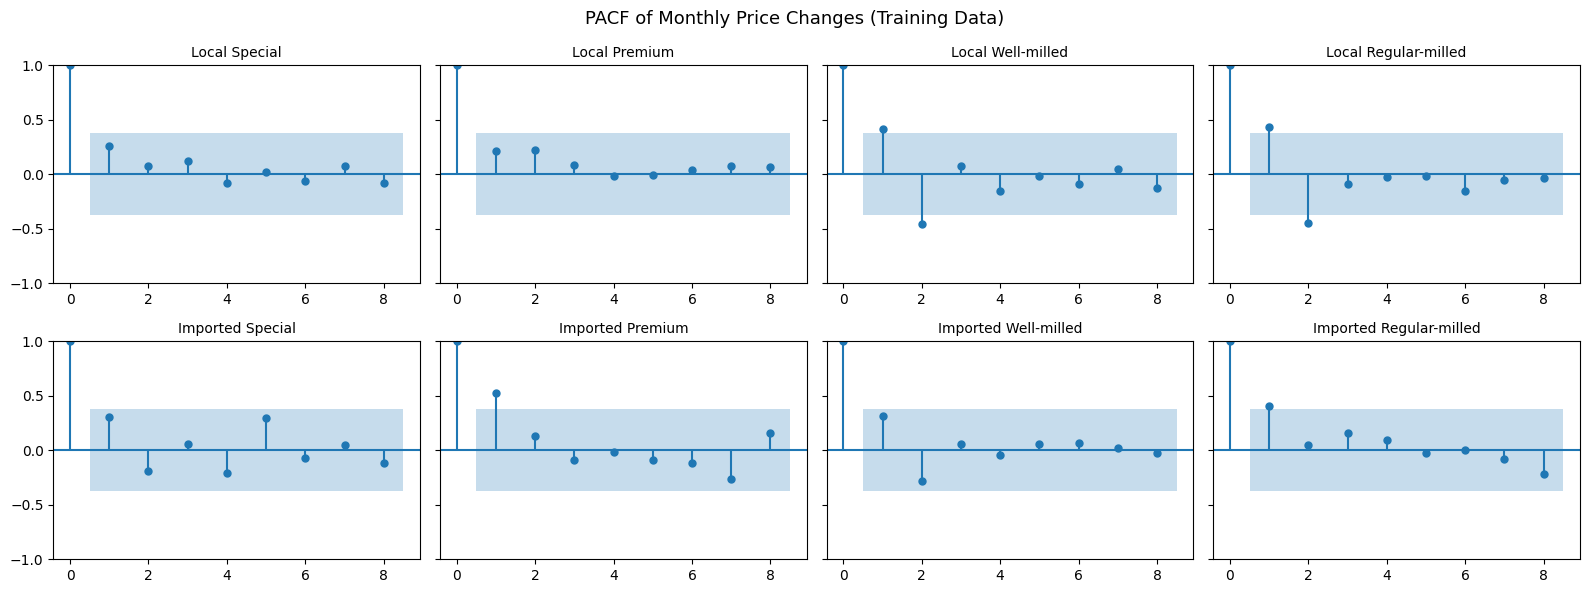

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

# Method 1: PACF of monthly price changes (differenced, so the series is stationary) on training data only
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
for ax, s in zip(axes.flat, SERIES):
    y_tr = data[(data["Series"] == s) & (data["Date"] <= TRAIN_END)].sort_values("Date")["Price"]
    plot_pacf(y_tr.diff().dropna(), lags=min(8, len(y_tr) // 2 - 2), ax=ax, method="ywm")
    ax.set_title(s, fontsize=10)
fig.suptitle("PACF of Monthly Price Changes (Training Data)", fontsize=13)
plt.tight_layout(); plt.show()

,h=1,h=2,h=3,h=4,h=5,h=6,Average MAE
PRICE_LAGS,,,,,,,
1,0.6295,1.1642,1.7726,2.5639,4.9966,5.4580,2.7641
2,0.6285,1.3272,1.6047,2.7142,5.1930,5.9019,2.8949
3,0.7350,1.0470,1.7775,3.1295,5.0752,5.6038,2.8947
4,0.7713,1.8251,3.0595,3.9847,5.0016,5.4839,3.3544
5,0.7618,1.9848,3.1309,4.1561,5.2127,5.9514,3.5329
6,0.7685,2.0231,3.4468,4.6916,5.6452,6.3792,3.8258


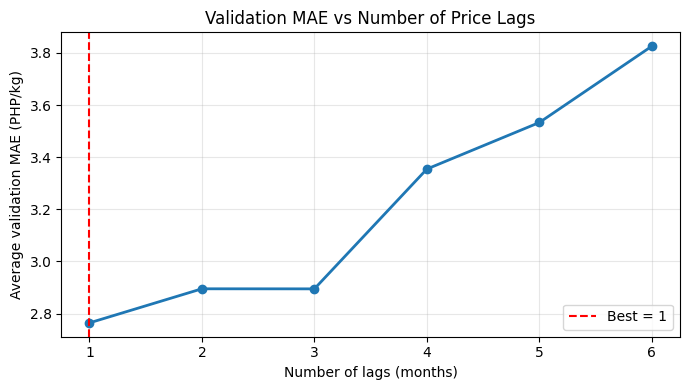

Selected PRICE_LAGS = 1  (26 features)


In [10]:
# Method 2: Lag search on the validation set (average over all horizons)
BASE_PARAMS = dict(max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, gamma=0.1)

lag_results = []
for L in range(1, 7):
    PRICE_LAGS = L
    maes = []
    for h in HORIZONS:
        f = make_features(data, h)
        FEATURES = [c for c in f.columns if c not in META]
        val = f[f["Set"] == "Validation"]
        pred = pd.Series(index=val.index, dtype=float)
        for origin in np.sort(val["Origin_Date"].unique()):
            known = f[f["Target_Date"] <= origin]
            m = xgb.XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, **BASE_PARAMS)
            m.fit(known[FEATURES], known["y"])
            idx = val.index[val["Origin_Date"] == origin]
            pred.loc[idx] = m.predict(f.loc[idx, FEATURES])
        maes.append(mean_absolute_error(val["Actual"], val["Base_Price"] + pred))
    lag_results.append({"PRICE_LAGS": L, **{f"h={h}": v for h, v in zip(HORIZONS, maes)},
                        "Average MAE": np.mean(maes)})

lag_table = pd.DataFrame(lag_results).set_index("PRICE_LAGS")
best_lag = int(lag_table["Average MAE"].idxmin())
display(lag_table.round(4))

plt.figure(figsize=(7, 4))
plt.plot(lag_table.index, lag_table["Average MAE"], "o-", linewidth=2)
plt.axvline(best_lag, color="red", linestyle="--", label=f"Best = {best_lag}")
plt.title("Validation MAE vs Number of Price Lags"); plt.xlabel("Number of lags (months)")
plt.ylabel("Average validation MAE (PHP/kg)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Use the best number of lags for the rest of the notebook
PRICE_LAGS = best_lag
FEATURES = [c for c in make_features(data, 1).columns if c not in META]
print(f"Selected PRICE_LAGS = {PRICE_LAGS}  ({len(FEATURES)} features)")

**Lag count used in this notebook.** In the lag search above, 1, 2 and 3 lags score almost the same (within about 0.05 PHP/kg average MAE), so the winner can change with the library version. To compare against the saved main results, this notebook uses the same value as the main notebook: **3 lags**.

In [11]:
PRICE_LAGS = 3
FEATURES = [c for c in make_features(data, 1).columns if c not in META]
print(f"Using PRICE_LAGS = {PRICE_LAGS}  ({len(FEATURES)} features)")

Using PRICE_LAGS = 3  (30 features)


## 7. Run everything: tuning + walk-forward for each horizon
This takes a few minutes.

In [12]:
warnings.filterwarnings("ignore")   # hide ARIMA fitting warnings
results, models, feats, tuned = [], {}, {}, {}
arima_cache = {}   # (series, origin) -> forecasts for 1..max(HORIZONS)

for h in HORIZONS:
    feat = make_features(data, h)
    params, n_rounds = tune_xgb(feat)
    xgb_pred, last_model = walk_forward_xgb(feat, params, n_rounds)
    models[h], feats[h], tuned[h] = last_model, feat, {**params, "n_estimators": n_rounds}

    ev = feat[feat["Set"] != "Train"].copy()
    ev["XGBoost"] = xgb_pred
    ev["Naive"] = ev["Base_Price"]

    arima_pred = []
    for _, r in ev.iterrows():
        key = (r["Series"], r["Origin_Date"])
        if key not in arima_cache:
            hist = data[(data["Series"] == r["Series"]) & (data["Date"] <= r["Origin_Date"])]
            hist = hist.sort_values("Date")["Price"].values
            arima_cache[key] = ARIMA(hist, order=arima_orders[r["Series"]]).fit().forecast(max(HORIZONS))
        arima_pred.append(arima_cache[key][h - 1])
    ev["ARIMA"] = arima_pred
    ev["Horizon"] = h
    results.append(ev[["Horizon", "Series", "Origin_Date", "Target_Date", "Set",
                       "Actual", "XGBoost", "ARIMA", "Naive"]])
    print(f"h={h}: done | best settings: {tuned[h]}")

preds = pd.concat(results, ignore_index=True)
MODELS = ["XGBoost", "ARIMA", "Naive"]

h=1: done | best settings: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8, 'n_estimators': 519}


h=2: done | best settings: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8, 'n_estimators': 385}


h=3: done | best settings: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.8, 'n_estimators': 181}


h=4: done | best settings: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.8, 'n_estimators': 176}


h=5: done | best settings: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7, 'n_estimators': 173}


h=6: done | best settings: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.7, 'n_estimators': 1}


## 13. Ablation: price history only vs. price history + market factors
Same tuning and walk-forward setup, but the model only sees past prices, price changes, rice type and season. If the full model has lower error, the market factors add real predictive value.

Full model: 30 features | Price-only model: 14 features


,Price-only MAE,Full model MAE,Price-only MAPE (%),Full model MAPE (%),Factors help,MAE reduction from factors (%)
Horizon,,,,,,
1,0.9801,1.0219,1.9311,2.0024,False,-4.2714
2,1.8815,1.8654,3.6368,3.5781,True,0.8548
3,2.7690,2.5045,5.4226,4.8450,True,9.5532
4,4.7812,3.8756,9.4083,7.5979,True,18.9402
5,6.2502,5.0217,12.2610,9.8606,True,19.6555
6,7.3413,7.2788,14.3628,14.2412,True,0.8516


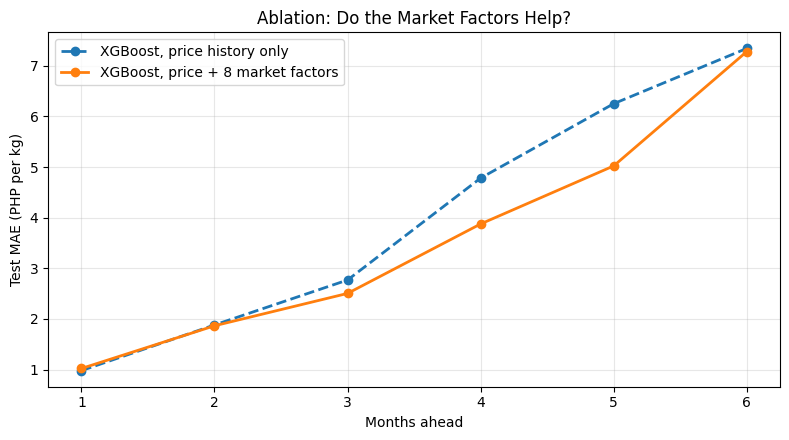

In [13]:
FEATURES_FULL = list(FEATURES)
FEATURES_PRICE_ONLY = [c for c in FEATURES_FULL if not any(c.startswith(e) for e in EXOG)]
print(f"Full model: {len(FEATURES_FULL)} features | Price-only model: {len(FEATURES_PRICE_ONLY)} features")

ablation_rows, ablation_preds = [], {}
FEATURES = FEATURES_PRICE_ONLY
for h in HORIZONS:
    feat = feats[h]
    params, n_rounds = tune_xgb(feat)
    pred, _ = walk_forward_xgb(feat, params, n_rounds)
    ablation_preds[h] = pred
    test = preds[(preds["Horizon"] == h) & (preds["Set"] == "Test")]
    po = pred.loc[feat.index[feat["Set"] == "Test"]].values
    full_mae = mean_absolute_error(test["Actual"], test["XGBoost"])
    po_mae = mean_absolute_error(test["Actual"], po)
    ablation_rows.append({"Horizon": h,
                          "Price-only MAE": po_mae, "Full model MAE": full_mae,
                          "Price-only MAPE (%)": mape(test["Actual"], po),
                          "Full model MAPE (%)": mape(test["Actual"], test["XGBoost"]),
                          "Factors help": full_mae < po_mae,
                          "MAE reduction from factors (%)": (po_mae - full_mae) / po_mae * 100})
FEATURES = FEATURES_FULL   # restore

ablation = pd.DataFrame(ablation_rows).set_index("Horizon")
display(ablation.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ablation.index, ablation["Price-only MAE"], "o--", label="XGBoost, price history only", linewidth=2)
ax.plot(ablation.index, ablation["Full model MAE"], "o-", label="XGBoost, price + 8 market factors", linewidth=2)
ax.set_xlabel("Months ahead"); ax.set_ylabel("Test MAE (PHP per kg)")
ax.set_title("Ablation: Do the Market Factors Help?"); ax.set_xticks(HORIZONS)
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## 14. Diebold-Mariano test
Tests whether two forecasts have **equal accuracy** (null hypothesis). Loss = absolute error. For each target month, the loss difference is averaged over the 8 rice types, giving one time series per horizon. Uses the Harvey-Leybourne-Newbold small-sample correction and a one-sided alternative (*XGBoost is more accurate*).

Run on the **validation + test** months, because the test set alone has very few months. With this many months the test has low power, so a non-significant result means "not enough evidence yet", not "no difference".

In [14]:
from scipy import stats

def dm_test(loss_a, loss_b, h):
    d = np.asarray(loss_a) - np.asarray(loss_b)       # negative mean = model A more accurate
    T = len(d)
    d_bar = d.mean()
    gamma = [np.mean((d[k:] - d_bar) * (d[:T - k] - d_bar)) for k in range(h)]
    var = (gamma[0] + 2 * sum(gamma[1:])) / T
    if var <= 0:
        return np.nan, np.nan, T
    dm = d_bar / np.sqrt(var)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)  # Harvey-Leybourne-Newbold correction
    stat = dm * hln
    p = stats.t.cdf(stat, df=T - 1)                     # one-sided: A better than B
    return stat, p, T

dm_rows = []
for h in HORIZONS:
    ev = preds[(preds["Horizon"] == h) & (preds["Set"] != "Train")].copy()
    for m in MODELS:
        ev[f"loss_{m}"] = (ev["Actual"] - ev[m]).abs()
    by_date = ev.groupby("Target_Date")[[f"loss_{m}" for m in MODELS]].mean()
    for other in ["ARIMA", "Naive"]:
        stat, p, T = dm_test(by_date["loss_XGBoost"], by_date[f"loss_{other}"], h)
        dm_rows.append({"Horizon": h, "XGBoost vs": other, "Months tested": T,
                        "DM statistic": stat, "p-value (one-sided)": p,
                        "Significant at 5%": bool(p < 0.05) if p == p else False,
                        "Significant at 10%": bool(p < 0.10) if p == p else False})

dm_table = pd.DataFrame(dm_rows)
display(dm_table.round(4))

,Horizon,XGBoost vs,Months tested,DM statistic,p-value (one-sided),Significant at 5%,Significant at 10%
0,1,ARIMA,7,-2.0010,0.0461,True,True
1,1,Naive,7,-1.4498,0.0986,False,True
2,2,ARIMA,7,-1.3116,0.1188,False,False
3,2,Naive,7,-0.6152,0.2805,False,False
4,3,ARIMA,7,-0.1882,0.4285,False,False
5,3,Naive,7,-0.4674,0.3284,False,False
6,4,ARIMA,7,0.7098,0.7478,False,False
7,4,Naive,7,0.7063,0.7468,False,False
8,5,ARIMA,7,2.3358,0.9709,False,False
9,5,Naive,7,NaN,NaN,False,False


## 15. Future forecast (beyond the last observed month)
For each horizon, XGBoost is retrained on **all** months with a known outcome (using the tuned settings from Section 7), then forecasts from the **last observed month**. These are real forecasts: the target months are not in the dataset yet.

The market factors at the forecast origin are the last observed values. SHAP contributions show which factors pushed each forecast up or down.

In [15]:
def origin_rows(df, h):
    # Same features as make_features, but only for the last observed month of each series,
    # where the target (t + h) is still unknown.
    parts = []
    for s, g in df.groupby("Series"):
        g = g.sort_values("Date").reset_index(drop=True)
        f = pd.DataFrame({"Series": s, "Origin": g["Origin"], "Variety": g["Variety"],
                          "Origin_Date": g["Date"]})
        for k in range(PRICE_LAGS + 1):
            f[f"Price_lag{k}"] = g["Price"].shift(k)
        for k in range(PRICE_LAGS):
            f[f"Change_lag{k}"] = g["Price"].shift(k) - g["Price"].shift(k + 1)
        for c in EXOG:
            f[f"{c}_lag0"] = g[c]
            f[f"{c}_lag1"] = g[c].shift(1)
        f["Target_Date"] = f["Origin_Date"] + pd.DateOffset(months=h)
        f["Target_Month"] = f["Target_Date"].dt.month
        f["Base_Price"] = g["Price"]
        parts.append(f.iloc[[-1]])
    out = pd.concat(parts, ignore_index=True)
    out = pd.get_dummies(out, columns=["Origin", "Variety"], dtype=int)
    for c in FEATURES:
        if c not in out:
            out[c] = 0
    return out

def factor_of(col):
    if col.startswith(("Price_lag", "Change_lag")): return "Price history"
    if col.startswith(("Origin_", "Variety_")):     return "Rice type (categorical)"
    if col == "Target_Month":                        return "Season (month)"
    for c in EXOG:
        if col.startswith(c): return c
    return col

future_rows, future_shap = [], []
for h in HORIZONS:
    feat = feats[h]
    params = {k: v for k, v in tuned[h].items() if k != "n_estimators"}
    model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=int(tuned[h]["n_estimators"]),
                             random_state=RANDOM_STATE, **params)
    model.fit(feat[FEATURES], feat["y"])
    o = origin_rows(data, h)
    change = model.predict(o[FEATURES])
    contrib = model.get_booster().predict(xgb.DMatrix(o[FEATURES]), pred_contribs=True)[:, :-1]
    contrib = pd.DataFrame(contrib, columns=FEATURES)
    by_factor = contrib.T.groupby(contrib.columns.map(factor_of)).sum().T
    t = preds[(preds["Horizon"] == h) & (preds["Set"] == "Test")]
    mape_test = t.groupby("Series").apply(lambda g: mape(g["Actual"], g["XGBoost"]))
    for i, r in o.iterrows():
        price = r["Base_Price"] + change[i]
        future_rows.append({"Horizon": h, "Series": r["Series"],
                            "Origin_Date": r["Origin_Date"], "Target_Date": r["Target_Date"],
                            "Base_Price": r["Base_Price"], "Forecast": price,
                            "Change (%)": change[i] / r["Base_Price"] * 100,
                            "Test MAPE (%)": mape_test.get(r["Series"], np.nan)})
        for fac, val in by_factor.iloc[i].items():
            future_shap.append({"Horizon": h, "Series": r["Series"], "Factor": fac, "SHAP (PHP/kg)": val})

future = pd.DataFrame(future_rows)
future_shap = pd.DataFrame(future_shap)
print(f"Last observed month: {data['Date'].max():%B %Y}")
display(future.pivot(index="Series", columns="Horizon", values="Forecast").round(2)
        .rename(columns=lambda h: f"{h} mo ahead"))

Last observed month: June 2026


Horizon,1 mo ahead,2 mo ahead,3 mo ahead,4 mo ahead,5 mo ahead,6 mo ahead
Series,,,,,,
Imported Premium,50.160000,51.080002,52.220001,52.250000,52.610001,50.099998
Imported Regular-milled,44.689999,45.099998,46.139999,46.779999,47.369999,43.419998
Imported Special,59.230000,59.509998,59.860001,60.540001,60.740002,58.910000
Imported Well-milled,47.720001,48.310001,49.330002,50.119999,50.410000,47.209999
Local Premium,54.009998,54.740002,55.419998,55.959999,56.009998,53.869999
Local Regular-milled,44.840000,45.500000,46.720001,47.439999,47.790001,44.060001
Local Special,59.669998,59.950001,60.529999,61.060001,61.150002,59.250000
Local Well-milled,48.990002,50.040001,51.189999,51.209999,51.430000,48.730000


## 16. Save results

In [16]:
with pd.ExcelWriter("P-RICE Extra Results.xlsx") as w:
    ablation.round(4).to_excel(w, sheet_name="Ablation")
    dm_table.round(4).to_excel(w, sheet_name="Diebold-Mariano", index=False)
    future.round(4).to_excel(w, sheet_name="Future Forecast", index=False)
    future_shap.round(4).to_excel(w, sheet_name="Future SHAP", index=False)
print("Saved: P-RICE Extra Results.xlsx")

Saved: P-RICE Extra Results.xlsx
